# Étape 3 — Score d'anomalie et calibration du seuil (`pill`)

TP B6, partie 2. Utilise le modèle entraîné (notebook 04) pour calculer un score
d'anomalie par image, calibrer un seuil de détection sur les pièces saines de
validation, puis évaluer ce score sur l'ensemble du jeu de test (saines + tous les
défauts).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from indusense.vision.anomaly import (
    calibrate_threshold,
    confusion,
    error_maps,
    image_auroc,
    image_scores,
    reconstruct,
)
from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)
from indusense.vision.train import load_trained_model

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model = load_trained_model()
display(Markdown(f"- **Modèle chargé** : {model.count_params()} paramètres."))

- **Modèle chargé** : 57235 paramètres.

## Décision — reconstituer le split de validation

**Décision** : recharger les pièces saines d'entraînement et refaire le split
train/validation avec exactement les mêmes paramètres qu'au notebook 04
(`val_fraction=0.15`, `seed=42`), sans régénérer les versions augmentées.

**Pourquoi** : le seuil doit être calibré sur des images que le modèle n'a **jamais**
vues à l'entraînement — c'est le rôle de `val_good` défini en partie 1 et repris par
`build_training_set`. Réutiliser directement `build_training_set` ici régénérerait
aussi les variantes augmentées de chaque image d'entraînement (coûteux et inutile ici
: seul `val_good` sert dans ce notebook). Reproduire le split avec la même graine
donne exactement le même ensemble de validation, sans ce coût.

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
_train_raw, val_good = train_val_split(good_train, val_fraction=0.15, seed=42)

display(
    Markdown(
        f"- **Saines de validation** : {val_good.shape[0]} images "
        "(jamais vues à l'entraînement)."
    )
)

- **Saines de validation** : 40 images (jamais vues à l'entraînement).

## Décision — calibrer le seuil sur les saines de validation uniquement

**Décision** : calculer le score d'anomalie (erreur de reconstruction moyenne) sur
`val_good`, puis calibrer le seuil avec les deux méthodes proposées par l'énoncé :
percentile 99 (retenu comme seuil principal) et moyenne + 3 écarts-types (calculée à
titre de comparaison).

**Pourquoi** : calibrer sur le test reviendrait à choisir un seuil avec les données
qu'on évalue ensuite (fuite). Le percentile 99 est retenu comme seuil principal car il
ne suppose aucune forme particulière pour la distribution des scores sains —
contrairement à moyenne ± k·écart-type, qui suppose implicitement une distribution
proche de la normale, une hypothèse peu justifiée pour une erreur de reconstruction
(positive par construction, potentiellement asymétrique).

In [3]:
reconstructions_val = reconstruct(model, val_good)
maps_val = error_maps(val_good, reconstructions_val)
scores_val = image_scores(maps_val)

threshold_percentile = calibrate_threshold(scores_val, method="percentile", q=99.0)
threshold_mean_std = calibrate_threshold(scores_val, method="mean_std", k=3.0)

lines = [
    f"- **Score moyen (saines de validation)** : {scores_val.mean():.5f} "
    f"(écart-type {scores_val.std():.5f}).",
    f"- **Seuil percentile 99** (retenu) : {threshold_percentile:.5f}.",
    f"- **Seuil moyenne + 3·écart-type** (comparaison) : {threshold_mean_std:.5f}.",
]
display(Markdown(chr(10).join(lines)))

- **Score moyen (saines de validation)** : 0.00024 (écart-type 0.00002).
- **Seuil percentile 99** (retenu) : 0.00029.
- **Seuil moyenne + 3·écart-type** (comparaison) : 0.00032.

## Décision — jeu de test complet (saines + tous les défauts)

**Décision** : évaluer le score sur `test/good` et sur **toutes** les catégories de
défauts (`list_defects()`), avec un label binaire par image (0 = saine, 1 = défaut).

**Pourquoi** : l'histogramme et l'AUROC n'ont de sens que si l'évaluation couvre
l'ensemble des cas rencontrés en production, pas une seule catégorie de défaut choisie
arbitrairement.

In [4]:
test_good = load_good_images("test", IMAGE_SIZE)
defects = list_defects()
defect_images = {defect: load_defect_images(defect, IMAGE_SIZE) for defect in defects}

test_images = np.concatenate([test_good, *defect_images.values()], axis=0)
labels = np.concatenate(
    [np.zeros(len(test_good))] + [np.ones(len(images)) for images in defect_images.values()]
)

lines = [f"- **Saines de test** : {len(test_good)} images."]
lines += [f"- **{defect}** : {len(images)} images." for defect, images in defect_images.items()]
lines.append(f"- **Total test** : {len(test_images)} images ({int(labels.sum())} défauts).")
display(Markdown(chr(10).join(lines)))

- **Saines de test** : 26 images.
- **color** : 25 images.
- **combined** : 17 images.
- **contamination** : 21 images.
- **crack** : 26 images.
- **faulty_imprint** : 19 images.
- **pill_type** : 9 images.
- **scratch** : 24 images.
- **Total test** : 167 images (141 défauts).

## Livrable — histogramme des scores (saines vs défauts) et seuil

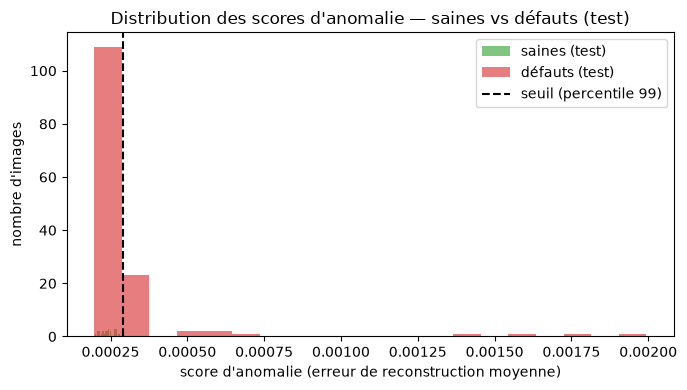

In [5]:
reconstructions_test = reconstruct(model, test_images)
maps_test = error_maps(test_images, reconstructions_test)
scores_test = image_scores(maps_test)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_test[labels == 0], bins=20, alpha=0.6, label="saines (test)", color="tab:green")
ax.hist(scores_test[labels == 1], bins=20, alpha=0.6, label="défauts (test)", color="tab:red")
ax.axvline(threshold_percentile, color="black", linestyle="--", label="seuil (percentile 99)")
ax.set_xlabel("score d'anomalie (erreur de reconstruction moyenne)")
ax.set_ylabel("nombre d'images")
ax.set_title("Distribution des scores d'anomalie — saines vs défauts (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_histogramme_scores.png", dpi=150)
plt.show()

In [6]:
frac_defects_overlap = (scores_test[labels == 1] <= threshold_percentile).mean()
frac_healthy_above = (scores_test[labels == 0] > threshold_percentile).mean()
max_score_healthy = scores_test[labels == 0].max()
frac_defects_above_healthy_max = (scores_test[labels == 1] > max_score_healthy).mean()

lines = [
    f"- **{frac_defects_overlap:.1%} des défauts** ont un score inférieur ou égal au "
    "seuil retenu : leur erreur de reconstruction est du même ordre que celle d'une "
    "pièce saine — le modèle les reconstruit trop bien pour les distinguer.",
    f"- **{frac_healthy_above:.1%} des saines de test** dépassent ce seuil (aucune "
    "fausse alerte ici, cohérent avec un seuil très conservateur au percentile 99).",
    f"- **{frac_defects_above_healthy_max:.1%} des défauts** ont un score strictement "
    f"supérieur au score maximal observé sur les saines de test "
    f"({max_score_healthy:.5f}) : ce sont les seuls cas détectables sans ambiguïté, "
    "quel que soit le seuil choisi.",
]
display(Markdown(chr(10).join(lines)))

- **83.0% des défauts** ont un score inférieur ou égal au seuil retenu : leur erreur de reconstruction est du même ordre que celle d'une pièce saine — le modèle les reconstruit trop bien pour les distinguer.
- **0.0% des saines de test** dépassent ce seuil (aucune fausse alerte ici, cohérent avec un seuil très conservateur au percentile 99).
- **27.0% des défauts** ont un score strictement supérieur au score maximal observé sur les saines de test (0.00028) : ce sont les seuls cas détectables sans ambiguïté, quel que soit le seuil choisi.

**Lecture de l'histogramme** : une large barre commune se concentre sur les scores les
plus bas, regroupant la quasi-totalité des saines **et** une majorité des défauts —
seule une minorité de défauts s'étend sur une longue traîne de scores nettement plus
élevés. C'est ce chevauchement, plutôt que la traîne, qui explique le rappel limité
obtenu plus loin au seuil percentile 99 (cf. matrice de confusion).

**Pourquoi ce chevauchement** : cohérent avec le compromis assumé au notebook 03 en
choisissant un ratio de compression serré (×12) plutôt que le ratio par défaut (×6) —
un bottleneck plus étroit *devrait* forcer le modèle à perdre plus de détails fins et
donc moins bien reconstruire les défauts, mais rien ne garantit que cette perte porte
spécifiquement sur les zones de défaut plutôt que sur l'image dans son ensemble. Ici,
une partie significative des défauts reste suffisamment subtile ou localisée pour ne
pas franchir un seuil de reconstruction **global**, moyenné sur toute l'image (256×256
pixels) — un défaut ponctuel dilue peu l'erreur moyenne.

## Livrable — AUROC niveau image

Mesure indépendante du seuil choisi : la capacité du score à séparer sain/défaut sur
l'ensemble des seuils possibles (1.0 = séparation parfaite, 0.5 = aléatoire). Sert de
première lecture quantitative de l'histogramme ci-dessus ; le pixel-AUROC et l'analyse
critique complète sont traités dans le notebook 06 (heatmaps sur les défauts réels).

In [7]:
auroc = image_auroc(scores_test, labels)
display(Markdown(f"- **AUROC image-level** : {auroc:.3f}."))

- **AUROC image-level** : 0.688.

In [8]:
lines = [
    f"- **Interprétation** : si on tire au hasard une image saine et une image "
    f"défectueuse, l'image défectueuse obtient un score d'anomalie plus élevé dans "
    f"{auroc:.1%} des cas (AUROC = {auroc:.3f}).",
    "- Un AUROC de 0.5 correspondrait à un classement aléatoire (aucun pouvoir "
    "séparateur) ; 1.0 à une séparation parfaite entre saines et défauts.",
    f"- {auroc:.3f} traduit un pouvoir séparateur **réel mais modéré** : le score "
    "distingue mieux que le hasard, mais reste loin d'une séparation fiable pour un "
    "usage en production sans seuil soigneusement choisi et contrôle humain en filet "
    "de sécurité — cohérent avec le chevauchement observé sur l'histogramme "
    "ci-dessus.",
]
display(Markdown(chr(10).join(lines)))

- **Interprétation** : si on tire au hasard une image saine et une image défectueuse, l'image défectueuse obtient un score d'anomalie plus élevé dans 68.8% des cas (AUROC = 0.688).
- Un AUROC de 0.5 correspondrait à un classement aléatoire (aucun pouvoir séparateur) ; 1.0 à une séparation parfaite entre saines et défauts.
- 0.688 traduit un pouvoir séparateur **réel mais modéré** : le score distingue mieux que le hasard, mais reste loin d'une séparation fiable pour un usage en production sans seuil soigneusement choisi et contrôle humain en filet de sécurité — cohérent avec le chevauchement observé sur l'histogramme ci-dessus.

## Discussion — arbitrage rappel / fausses alertes au seuil retenu

**Décision** : donner un instantané chiffré (rappel, précision, taux de fausses
alertes) au seuil percentile 99 pour ancrer la discussion dans des valeurs réelles,
plutôt que de la garder purement qualitative.

**Pourquoi cet arbitrage compte** : en contrôle qualité pharmaceutique, laisser passer
une pièce défectueuse (faux négatif) est presque toujours plus coûteux qu'une fausse
alerte (faux positif, qui ne coûte qu'une inspection manuelle supplémentaire). Un seuil
plus bas (percentile inférieur à 99, ou un `k` plus petit pour la méthode
moyenne+k·écart-type) augmenterait le rappel au prix de plus de fausses alertes. Le
choix définitif du seuil de production est une décision **métier** (coût d'un défaut
non détecté vs coût d'une inspection manuelle), pas seulement statistique — cette
cellule ne fait que fournir les chiffres nécessaires à cet arbitrage, pas le trancher.
Une matrice de confusion plus détaillée (par catégorie de défaut) est établie au
notebook 06.

In [9]:
cm = confusion(scores_test, labels, threshold_percentile)
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else float("nan")

lines = [
    f"- **Matrice de confusion** (seuil percentile 99) : "
    f"VN={tn}, FP={fp}, FN={fn}, VP={tp}.",
    f"- **Rappel (sensibilité)** : {recall:.1%} des défauts sont détectés.",
    f"- **Précision** : {precision:.1%} des alertes correspondent à un vrai défaut.",
    f"- **Taux de fausses alertes** : {false_alarm_rate:.1%} des pièces saines sont "
    f"signalées à tort.",
]
if fn > 0:
    lines.append(
        f"- **{fn} défaut(s) non détecté(s)** au seuil actuel — à mettre en balance "
        "avec le coût métier d'un faux négatif avant de valider ce seuil en production."
    )
display(Markdown(chr(10).join(lines)))

- **Matrice de confusion** (seuil percentile 99) : VN=26, FP=0, FN=117, VP=24.
- **Rappel (sensibilité)** : 17.0% des défauts sont détectés.
- **Précision** : 100.0% des alertes correspondent à un vrai défaut.
- **Taux de fausses alertes** : 0.0% des pièces saines sont signalées à tort.
- **117 défaut(s) non détecté(s)** au seuil actuel — à mettre en balance avec le coût métier d'un faux négatif avant de valider ce seuil en production.

## Recommandations

- **Seuil de production** : partir du percentile 99 calculé ici, mais le faire valider
  par le métier à la lumière du rappel/taux de fausses alertes affichés ci-dessus — un
  seuil plus bas serait probablement préférable si le coût d'un défaut non détecté est
  élevé (cf. discussion ci-dessus).
- **Recalibrage** : si le procédé de fabrication évolue (nouvel outillage, nouvel
  éclairage de la caméra), recalibrer le seuil sur un nouvel échantillon de pièces
  saines plutôt que réutiliser tel quel le seuil ci-dessus.
- **Prochaine étape (notebook 06)** : visualiser les heatmaps d'erreur sur des défauts
  réels, calculer le pixel-AUROC via les masques de vérité terrain, et discuter les
  limites observées à la lumière du ratio de compression ×12 retenu au notebook 03.